<a href="https://colab.research.google.com/github/harshal8704/NNDL-Practicals/blob/main/NNDL_Prac7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install ultralytics -q

In [20]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load the pretrained YOLO26 model (nano version – smallest and fastest)
model = YOLO("yolo26n.pt")

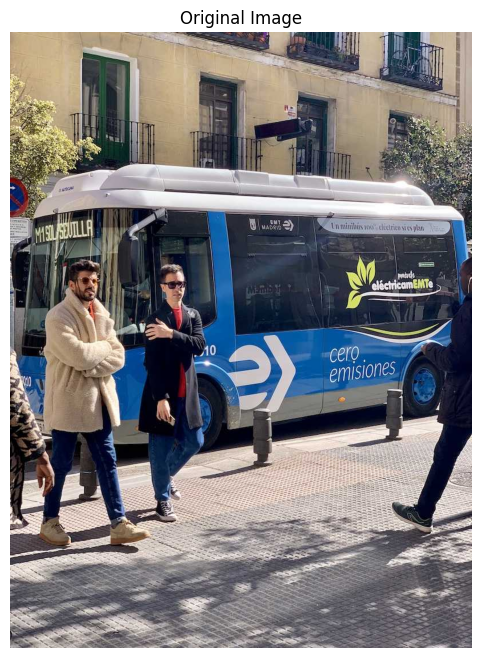

In [21]:
# Download a sample image (you can replace with your own)
!wget -q https://ultralytics.com/images/bus.jpg -O sample.jpg

# Display the original image
img = Image.open("sample.jpg")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()


image 1/1 /content/models/research/models/research/sample.jpg: 640x480 4 persons, 1 bus, 131.7ms
Speed: 4.7ms preprocess, 131.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/models/research/models/research/runs/detect/predict


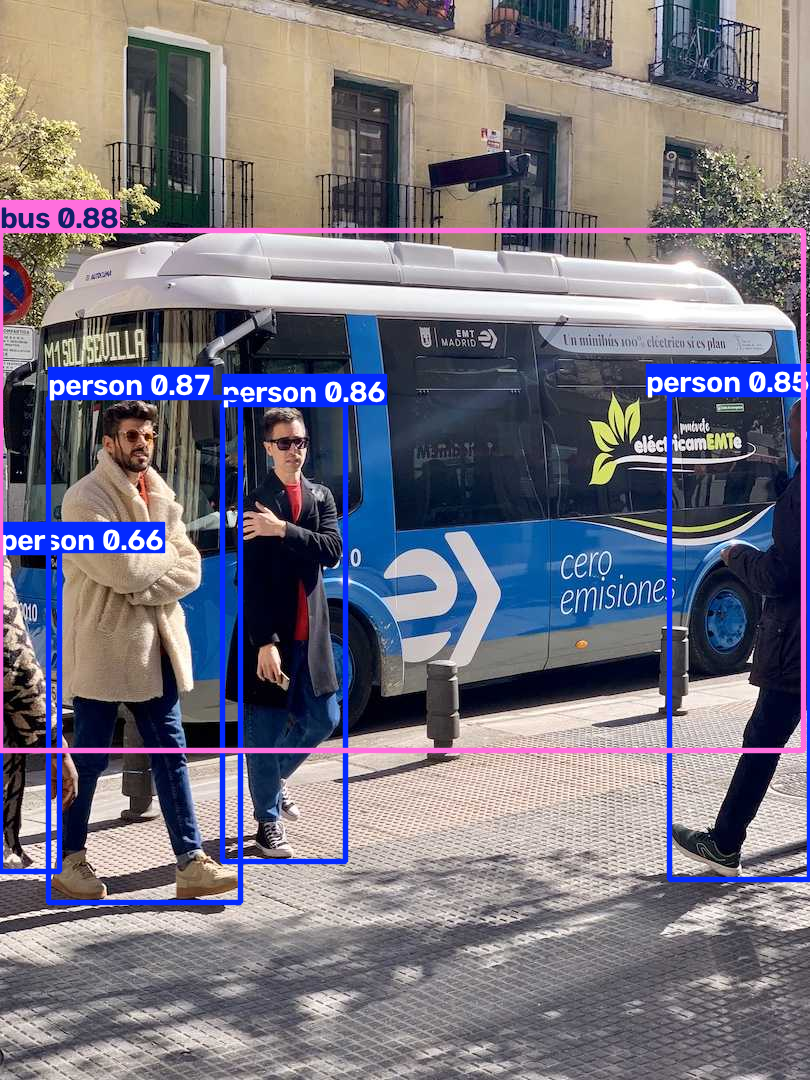

In [22]:
# Run inference
results = model("sample.jpg", conf=0.25, save=True)

# The results object contains detections; show the annotated image
results[0].show()

In [23]:
# Get the first result
r = results[0]

# Bounding boxes in xyxy format (top-left x, top-left y, bottom-right x, bottom-right y)
boxes = r.boxes.xyxy.cpu().numpy()

# Confidence scores
confidences = r.boxes.conf.cpu().numpy()

# Class IDs
class_ids = r.boxes.cls.cpu().numpy()

# Class names (from the COCO dataset)
class_names = r.names

# Print detected objects
for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
    x1, y1, x2, y2 = box
    label = class_names[int(cls_id)]
    print(f"Object {i+1}: {label} (confidence: {conf:.2f}) at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")

Object 1: bus (confidence: 0.88) at [0, 230, 803, 751]
Object 2: person (confidence: 0.87) at [49, 398, 240, 902]
Object 3: person (confidence: 0.86) at [223, 405, 345, 861]
Object 4: person (confidence: 0.85) at [670, 394, 810, 879]
Object 5: person (confidence: 0.66) at [0, 553, 60, 871]
